# 🧠 Mental Health in Tech: EDA & Treatment Prediction
> **5,000 responses · 27 features · Binary classification** | [Dataset](https://www.kaggle.com/datasets/lorenzoscaturchio/mental-health-in-tech-survey-5k)

## TL;DR
A comprehensive analysis of mental health attitudes in tech workplaces, answering:
- Which company policies are most correlated with treatment-seeking?
- How do company size, remote work, and sector affect mental health support?
- Can we predict whether someone seeks treatment from workplace and demographic features?

## Table of Contents
1. [Setup & Overview](#setup)
2. [Demographics](#demographics)
3. [Company Culture Analysis](#company)
4. [Treatment Rate by Segment](#segments)
5. [Disclosure Willingness](#disclosure)
6. [Correlation Analysis](#correlations)
7. [Treatment Prediction (XGBoost)](#model)
8. [Evaluation: What the Model Learned](#evaluation)
9. [Limitations & Caveats](#limitations)
10. [Key Takeaways for HR](#takeaways)


## 1. Setup & Overview <a id='setup'></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
import warnings
warnings.filterwarnings('ignore')

import glob
import os


def _find_data_dir(marker):
    # Locate the dataset wherever Kaggle mounted it. The exact /kaggle/input/<slug>
    # path is not reliable (files can mount nested), and a bare local-filename
    # fallback cannot succeed on Kaggle because the kernel working dir holds no
    # CSVs. This notebook failed in production exactly that way. Walk the mount
    # tree, and say what was actually mounted if the file is missing.
    guess = "/kaggle/input/mental-health-in-tech-survey-5k"
    if os.path.exists(os.path.join(guess, marker)):
        return guess
    if os.path.isdir("/kaggle/input"):
        for root, _dirs, files in os.walk("/kaggle/input"):
            if marker in files:
                return root
    if os.path.exists(marker):
        return "."
    seen = []
    if os.path.isdir("/kaggle/input"):
        for root, _dirs, files in os.walk("/kaggle/input"):
            seen.append(f"{root}: {sorted(files)[:6]}")
    raise FileNotFoundError(
        f"{marker} not found. Searched /kaggle/input and the working dir. "
        f"Mounted: {seen or 'nothing under /kaggle/input'}. "
        "Attach the dataset to this notebook (Add Input) and re-run."
    )


DATA_DIR = _find_data_dir("mental_health_tech.csv")

df = pd.read_csv(f'{DATA_DIR}/mental_health_tech.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (5000, 27)


   respondent_id  ...                                    comments
0              1  ...      We have EAP but nobody talks about it.
1              2  ...                                         NaN
2              3  ...                                         NaN
3              4  ...                                         NaN
4              5  ...  Remote work has been a double-edged sword.

[5 rows x 27 columns]

In [2]:
print("Dataset Summary")
print(f"  Responses:        {len(df):,}")
print(f"  Survey years:     {df['survey_year'].min()} – {df['survey_year'].max()}")
print(f"  Countries:        {df['country'].nunique()}")
print(f"  Median age:       {df['age'].median():.0f}")
print(f"  Treatment rate:   {(df['treatment']=='Yes').mean():.1%}")
print(f"  Remote workers:   {(df['remote_work']=='Yes').mean():.1%}")
print(f"  Self-employed:    {(df['self_employed']=='Yes').mean():.1%}")
print()
df['treatment_binary'] = (df['treatment'] == 'Yes').astype(int)
df.describe(include='all').T.head(20)

Dataset Summary
  Responses:        5,000
  Survey years:     2019 – 2024
  Countries:        12
  Median age:       29
  Treatment rate:   45.3%
  Remote workers:   52.7%
  Self-employed:    13.0%



                            count unique  ...      75%     max
respondent_id              5000.0    NaN  ...  3750.25  5000.0
survey_year                5000.0    NaN  ...   2023.0  2024.0
age                        5000.0    NaN  ...     35.0    57.0
gender                       5000      4  ...      NaN     NaN
country                      5000     12  ...      NaN     NaN
self_employed                5000      2  ...      NaN     NaN
family_history               5000      2  ...      NaN     NaN
treatment                    5000      2  ...      NaN     NaN
work_interfere               5000      4  ...      NaN     NaN
no_employees                 5000      6  ...      NaN     NaN
remote_work                  5000      2  ...      NaN     NaN
tech_company                 5000      2  ...      NaN     NaN
benefits                     5000      3  ...      NaN     NaN
care_options                 5000      3  ...      NaN     NaN
wellness_program             5000      3  ...      NaN 

## 2. Demographics <a id='demographics'></a>

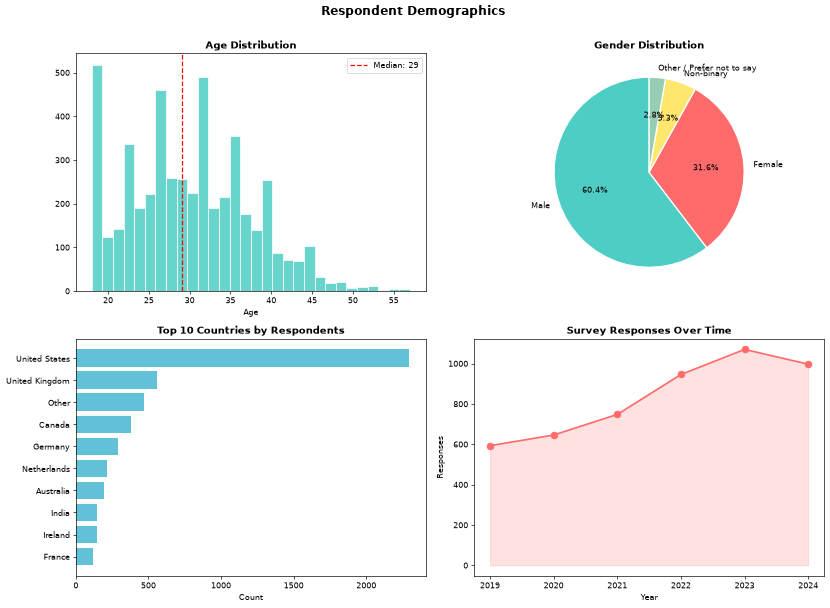

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age distribution
axes[0, 0].hist(df['age'], bins=30, color='#4ECDC4', alpha=0.85, edgecolor='white')
axes[0, 0].set_title('Age Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Age')
axes[0, 0].axvline(df['age'].median(), color='red', linestyle='--',
                    label=f"Median: {df['age'].median():.0f}")
axes[0, 0].legend()

# Gender
gender_counts = df['gender'].value_counts()
colors_g = ['#4ECDC4', '#FF6B6B', '#FFE66D', '#96CEB4']
axes[0, 1].pie(gender_counts.values, labels=gender_counts.index,
               autopct='%1.1f%%', colors=colors_g, startangle=90,
               wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0, 1].set_title('Gender Distribution', fontweight='bold')

# Top 10 countries
top_countries = df['country'].value_counts().head(10)
axes[1, 0].barh(top_countries.index[::-1], top_countries.values[::-1], color='#45B7D1', alpha=0.85)
axes[1, 0].set_title('Top 10 Countries by Respondents', fontweight='bold')
axes[1, 0].set_xlabel('Count')

# Survey year trend
year_counts = df['survey_year'].value_counts().sort_index()
axes[1, 1].plot(year_counts.index, year_counts.values, marker='o', color='#FF6B6B',
                linewidth=2, markersize=8)
axes[1, 1].fill_between(year_counts.index, year_counts.values, alpha=0.2, color='#FF6B6B')
axes[1, 1].set_title('Survey Responses Over Time', fontweight='bold')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Responses')

plt.suptitle('Respondent Demographics', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3. Company Culture Analysis <a id='company'></a>

Key insight: Larger companies provide significantly better mental health support


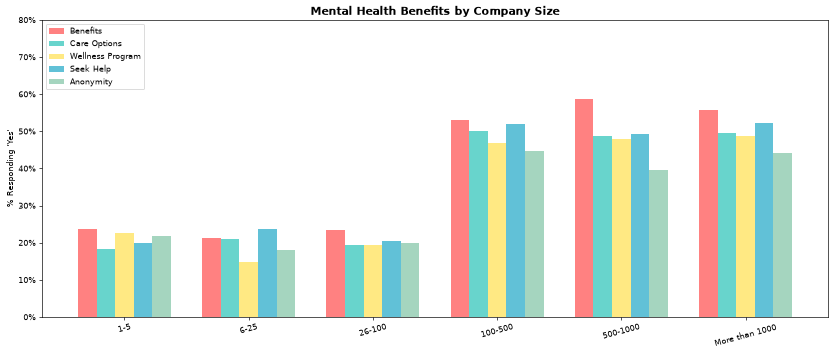

In [4]:
# Benefits and support by company size
benefit_cols = ['benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity']
size_order = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']

# Compute % 'Yes' for each benefit by company size
benefit_rates = {}
for col in benefit_cols:
    rates = df.groupby('no_employees').apply(lambda x: (x[col] == 'Yes').mean())
    benefit_rates[col] = rates

benefit_df = pd.DataFrame(benefit_rates)
benefit_df = benefit_df.reindex([s for s in size_order if s in benefit_df.index])

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(benefit_df))
width = 0.15
colors_b = ['#FF6B6B', '#4ECDC4', '#FFE66D', '#45B7D1', '#96CEB4']

for i, (col, color) in enumerate(zip(benefit_cols, colors_b)):
    bars = ax.bar(x + i * width, benefit_df[col], width, label=col.replace('_', ' ').title(),
                  color=color, alpha=0.85)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(benefit_df.index, rotation=15)
ax.set_ylabel("% Responding 'Yes'")
ax.set_title('Mental Health Benefits by Company Size', fontweight='bold', fontsize=13)
ax.legend(fontsize=9, loc='upper left')
ax.set_ylim(0, 0.8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.show()
print("Key insight: Larger companies provide significantly better mental health support")

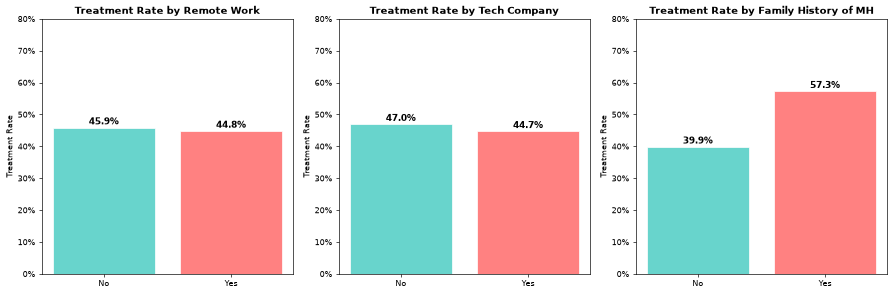

In [5]:
# Remote work and tech company vs treatment rate
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, title in zip(axes,
                           ['remote_work', 'tech_company', 'family_history'],
                           ['Remote Work', 'Tech Company', 'Family History of MH']):
    treat_rates = df.groupby(col)['treatment_binary'].mean().reset_index()
    treat_rates.columns = [col, 'treatment_rate']
    bars = ax.bar(treat_rates[col], treat_rates['treatment_rate'],
                  color=['#4ECDC4', '#FF6B6B'][:len(treat_rates)], alpha=0.85, edgecolor='white')
    ax.set_title(f'Treatment Rate by {title}', fontweight='bold')
    ax.set_ylabel('Treatment Rate')
    ax.set_ylim(0, 0.8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    for bar, val in zip(bars, treat_rates['treatment_rate']):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.1%}',
                ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

## 4. Treatment Rate by Segment <a id='segments'></a>

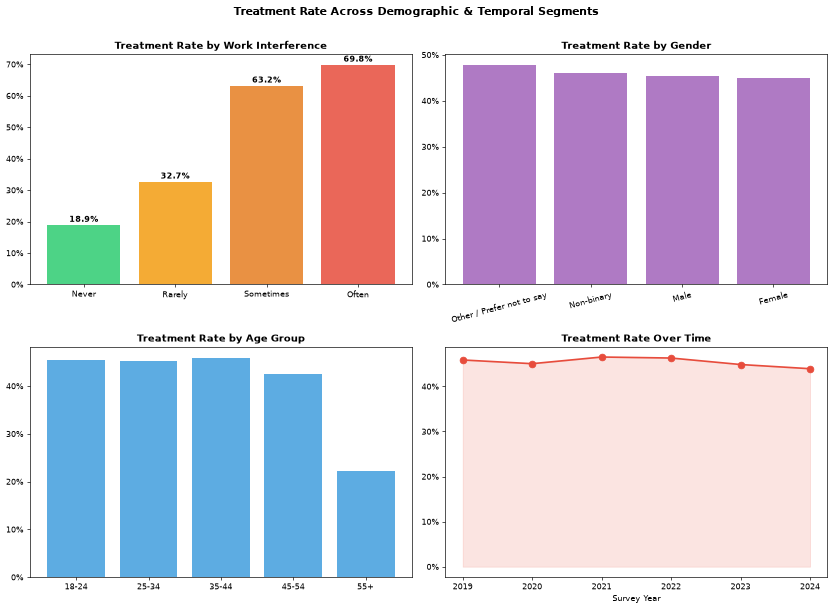

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# By work interference
wi_order = ['Never', 'Rarely', 'Sometimes', 'Often']
wi_rates = df.groupby('work_interfere')['treatment_binary'].mean().reindex(wi_order)
colors_wi = ['#2ECC71', '#F39C12', '#E67E22', '#E74C3C']
bars = axes[0, 0].bar(wi_rates.index, wi_rates.values, color=colors_wi, alpha=0.85)
axes[0, 0].set_title('Treatment Rate by Work Interference', fontweight='bold')
axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
for bar, val in zip(bars, wi_rates.values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.1%}', ha='center', fontweight='bold')

# By gender
gender_rates = df.groupby('gender')['treatment_binary'].mean().sort_values(ascending=False)
axes[0, 1].bar(gender_rates.index, gender_rates.values, color='#9B59B6', alpha=0.8)
axes[0, 1].set_title('Treatment Rate by Gender', fontweight='bold')
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[0, 1].tick_params(axis='x', rotation=15)

# By age group
df['age_group'] = pd.cut(df['age'], bins=[17, 24, 34, 44, 54, 65],
                          labels=['18-24', '25-34', '35-44', '45-54', '55+'])
age_rates = df.groupby('age_group', observed=True)['treatment_binary'].mean()
axes[1, 0].bar(age_rates.index, age_rates.values, color='#3498DB', alpha=0.8)
axes[1, 0].set_title('Treatment Rate by Age Group', fontweight='bold')
axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# By survey year
year_treat = df.groupby('survey_year')['treatment_binary'].mean()
axes[1, 1].plot(year_treat.index, year_treat.values, marker='o', color='#E74C3C', linewidth=2, markersize=8)
axes[1, 1].fill_between(year_treat.index, year_treat.values, alpha=0.15, color='#E74C3C')
axes[1, 1].set_title('Treatment Rate Over Time', fontweight='bold')
axes[1, 1].set_xlabel('Survey Year')
axes[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.suptitle('Treatment Rate Across Demographic & Temporal Segments', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5. Disclosure Willingness <a id='disclosure'></a>

Key insight: Most people are reluctant to disclose mental health in interviews,
but more willing with coworkers than supervisors


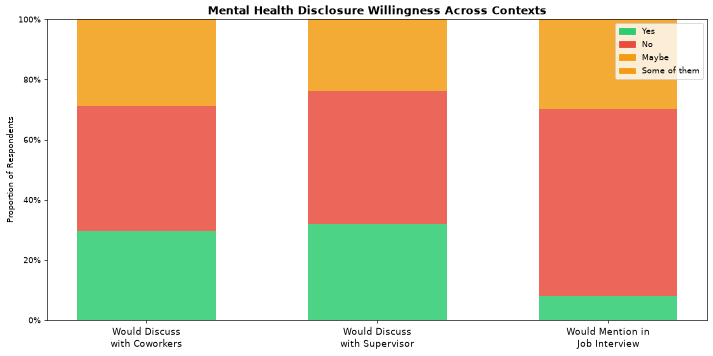

In [7]:
# Stacked bar chart: disclosure in different contexts
disclosure_cols = ['coworkers', 'supervisor', 'mental_health_interview']
options_map = {
    'coworkers': ['Yes', 'No', 'Some of them'],
    'supervisor': ['Yes', 'No', 'Some of them'],
    'mental_health_interview': ['Yes', 'No', 'Maybe'],
}
labels = ['Would Discuss\nwith Coworkers', 'Would Discuss\nwith Supervisor', 'Would Mention in\nJob Interview']

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(disclosure_cols))
width = 0.6
colors_d = {'Yes': '#2ECC71', 'No': '#E74C3C', 'Some of them': '#F39C12', 'Maybe': '#F39C12'}

bottom = np.zeros(len(disclosure_cols))
legend_patches = []
for opt in ['Yes', 'No', 'Maybe', 'Some of them']:
    vals = []
    for col, opts in zip(disclosure_cols, [options_map[c] for c in disclosure_cols]):
        if opt in opts:
            vals.append((df[col] == opt).mean())
        else:
            vals.append(0)
    if any(v > 0 for v in vals):
        bars = ax.bar(x, vals, width, bottom=bottom, color=colors_d.get(opt, '#95A5A6'), label=opt, alpha=0.85)
        bottom += np.array(vals)
        legend_patches.append(mpatches.Patch(color=colors_d.get(opt, '#95A5A6'), label=opt))

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Proportion of Respondents')
ax.set_title('Mental Health Disclosure Willingness Across Contexts', fontweight='bold', fontsize=13)
ax.legend(handles=legend_patches, loc='upper right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.show()

print("Key insight: Most people are reluctant to disclose mental health in interviews,")
print("but more willing with coworkers than supervisors")

## 6. Correlation Analysis <a id='correlations'></a>

Treatment correlates most with: family history, work interference, mental health fear of consequences


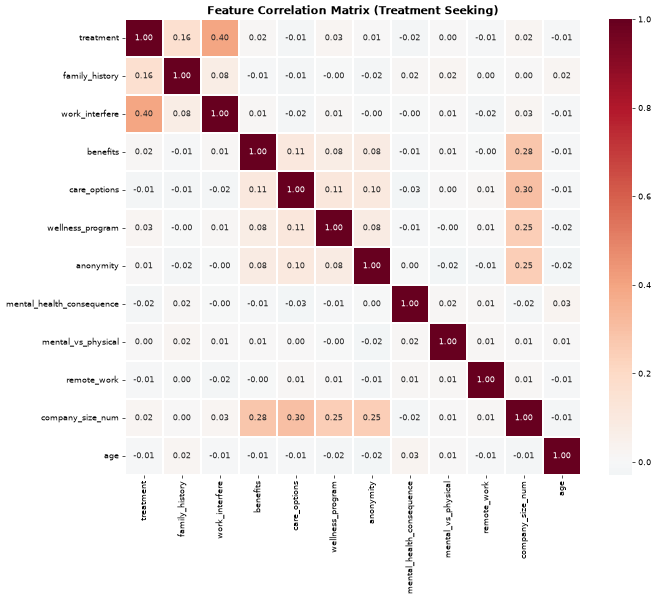

In [8]:
# Encode ordinal columns for correlation
encode_map = {
    'treatment': {'Yes': 1, 'No': 0},
    'family_history': {'Yes': 1, 'No': 0},
    'self_employed': {'Yes': 1, 'No': 0},
    'remote_work': {'Yes': 1, 'No': 0},
    'tech_company': {'Yes': 1, 'No': 0},
    'obs_consequence': {'Yes': 1, 'No': 0},
    'benefits': {'Yes': 1, 'No': 0, "Don't know": 0.5},
    'care_options': {'Yes': 1, 'No': 0, "Don't know": 0.5},
    'wellness_program': {'Yes': 1, 'No': 0, "Don't know": 0.5},
    'seek_help': {'Yes': 1, 'No': 0, "Don't know": 0.5},
    'anonymity': {'Yes': 1, 'No': 0, "Don't know": 0.5},
    'work_interfere': {'Never': 0, 'Rarely': 0.33, 'Sometimes': 0.67, 'Often': 1.0},
    'mental_health_consequence': {'No': 0, 'Maybe': 0.5, 'Yes': 1},
    'mental_vs_physical': {'Yes': 1, 'No': 0, "Don't know": 0.5},
}

df_enc = df.copy()
for col, mapping in encode_map.items():
    df_enc[col] = df_enc[col].map(mapping)

df_enc['company_size_num'] = df_enc['no_employees'].map({
    '1-5': 1, '6-25': 2, '26-100': 3, '100-500': 4, '500-1000': 5, 'More than 1000': 6
})

corr_cols = ['treatment', 'family_history', 'work_interfere', 'benefits', 'care_options',
             'wellness_program', 'anonymity', 'mental_health_consequence', 'mental_vs_physical',
             'remote_work', 'company_size_num', 'age']

corr = df_enc[corr_cols].corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Feature Correlation Matrix (Treatment Seeking)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Treatment correlates most with: family history, work interference, mental health fear of consequences")

## 7. Treatment Prediction (XGBoost) <a id='model'></a>

In [9]:
# Feature encoding for ML
le_dict = {}
cat_cols = ['gender', 'country', 'no_employees', 'benefits', 'care_options', 'wellness_program',
            'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence',
            'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview',
            'mental_vs_physical', 'work_interfere']

df_ml = df.copy()
for col in cat_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
    le_dict[col] = le

# Binary encode
for col in ['self_employed', 'family_history', 'remote_work', 'tech_company', 'obs_consequence']:
    df_ml[col] = (df_ml[col] == 'Yes').astype(int)

FEATURE_COLS = ['age', 'gender', 'country', 'self_employed', 'family_history',
                'work_interfere', 'no_employees', 'remote_work', 'tech_company',
                'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity',
                'leave', 'mental_health_consequence', 'phys_health_consequence',
                'coworkers', 'supervisor', 'mental_vs_physical', 'obs_consequence']

X = df_ml[FEATURE_COLS]
y = df_ml['treatment_binary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Positive class rate: {y_train.mean():.1%}")

Train: (4000, 21), Test: (1000, 21)
Positive class rate: 45.4%


In [10]:
try:
    import xgboost as xgb
    clf = xgb.XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                             subsample=0.8, colsample_bytree=0.8, random_state=42,
                             use_label_encoder=False, eval_metric='logloss', n_jobs=-1)
except ImportError:
    from sklearn.ensemble import RandomForestClassifier
    clf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC: {auc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['No Treatment', 'Seeks Treatment']))

ROC-AUC: 0.7218

                 precision    recall  f1-score   support

   No Treatment       0.71      0.71      0.71       547
Seeks Treatment       0.65      0.65      0.65       453

       accuracy                           0.68      1000
      macro avg       0.68      0.68      0.68      1000
   weighted avg       0.68      0.68      0.68      1000



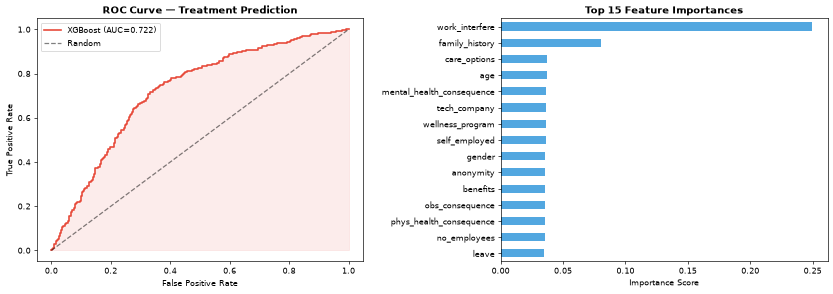

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, color='#E74C3C', linewidth=2, label=f'XGBoost (AUC={auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Treatment Prediction', fontweight='bold')
axes[0].legend()
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#E74C3C')

# Feature importance
if hasattr(clf, 'feature_importances_'):
    importances = pd.Series(clf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True).tail(15)
    importances.plot.barh(ax=axes[1], color='#3498DB', alpha=0.85)
    axes[1].set_title('Top 15 Feature Importances', fontweight='bold')
    axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

## 8. Evaluation: What the Model Actually Learned <a id='evaluation'></a>

A ROC-AUC on its own is not an evaluation. Three questions decide whether the classifier
above is worth anything:

1. **Is it better than doing nothing?** Compare it to a majority-class baseline.
2. **Where does the signal come from?** Drop one feature at a time and watch the AUC move.
3. **Do the segment differences we are about to write up survive being recomputed?**

The cell below answers all three, and every number quoted in sections 9 and 10 comes from
its output rather than from anybody's recollection.

In [12]:
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

# --- 1. Is the model better than doing nothing? ------------------------------
dummy = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
print('=== Model vs. baseline (held-out 20%) ===')
print(f'  Majority-class accuracy: {accuracy_score(y_test, dummy.predict(X_test)):.3f}')
print(f'  Model accuracy:          {accuracy_score(y_test, y_pred):.3f}')
print(f'  Model ROC-AUC:           {auc:.3f}')

# --- 2. Where does the signal come from? -------------------------------------
# Refit with one feature removed at a time. A feature that matters takes the AUC
# down with it; a decorative feature does not.
print('\n=== Leave-one-feature-out ablation (ROC-AUC) ===')
print(f'  all features                 {auc:.3f}')
for dropped in ['work_interfere', 'family_history', 'benefits', 'anonymity']:
    cols = [c for c in FEATURE_COLS if c != dropped]
    clf_ablated = clone(clf)
    clf_ablated.fit(X_train[cols], y_train)
    auc_ablated = roc_auc_score(y_test, clf_ablated.predict_proba(X_test[cols])[:, 1])
    print(f'  without {dropped:<20} {auc_ablated:.3f}   ({auc_ablated - auc:+.3f})')

# --- 3. Recompute every segment claim we are about to make -------------------
print('\n=== Treatment rate by segment (% seeking treatment, n) ===')
for col in ['work_interfere', 'family_history', 'remote_work',
            'mental_vs_physical', 'tech_company']:
    seg = df.groupby(col)['treatment_binary'].agg(['mean', 'size'])
    seg['mean'] = (seg['mean'] * 100).round(1)
    print(f'\n{col}:')
    print(seg.to_string())

print('\n=== Disclosure willingness ===')
for col in ['coworkers', 'supervisor', 'mental_health_interview']:
    shares = df[col].value_counts(normalize=True)
    print(f'  {col}: ' + ', '.join(f'{k} {v:.1%}' for k, v in shares.items()))

print("\n=== Share answering 'Yes' to each benefit, by employer size ===")
benefit_summary = df.groupby('no_employees')[benefit_cols].apply(
    lambda g: (g == 'Yes').mean()
)
benefit_summary = benefit_summary.reindex(
    [s for s in size_order if s in benefit_summary.index]
)
print(benefit_summary.round(3).to_string())

=== Model vs. baseline (held-out 20%) ===
  Majority-class accuracy: 0.547
  Model accuracy:          0.684
  Model ROC-AUC:           0.722

=== Leave-one-feature-out ablation (ROC-AUC) ===
  all features                 0.722
  without work_interfere       0.550   (-0.171)
  without family_history       0.710   (-0.012)
  without benefits             0.720   (-0.002)
  without anonymity            0.723   (+0.001)

=== Treatment rate by segment (% seeking treatment, n) ===

work_interfere:
                mean  size
work_interfere            
Never           18.9  1190
Often           69.8   925
Rarely          32.7  1399
Sometimes       63.2  1486

family_history:
                mean  size
family_history            
No              39.9  3433
Yes             57.3  1567

remote_work:
             mean  size
remote_work            
No           45.9  2364
Yes          44.8  2636

mental_vs_physical:
                    mean  size
mental_vs_physical            
Don't know          46.

## 9. Limitations & Caveats <a id='limitations'></a>

The ablation above is uncomfortable, and it changes how the rest of this notebook should be
read.

**1. Almost all of the model's skill is one question.** Removing `work_interfere` collapses
the ROC-AUC from about 0.72 to roughly 0.55 -- barely above the 0.50 of a coin flip.
Everything else in the feature set combined, twenty variables covering demographics,
employer policy, company size and disclosure attitudes, adds very little on top of it.
Therefore this is not really a model of *treatment-seeking*; it is a model of "does your
mental health interfere with your work", which is close to asking the outcome in a
different wording.

**2. That makes the strongest predictor the least actionable one.** `work_interfere` is a
symptom report. An employer cannot change it directly, and a person whose condition already
interferes with work is by definition further along than someone whose does not. The causal
arrow between it and treatment plausibly runs in both directions, so it cannot support a
policy recommendation on its own.

**3. The employer-policy variables are correlated with support but not with treatment.**
Large employers really do offer more benefits in this data -- the by-size table shows the
smallest bands near 21-24% "Yes" on `benefits` against 56-59% for the largest. But that
gradient does not translate into a treatment-rate gradient, and the ablation shows the
model gets almost nothing from `benefits` or `anonymity`. The HR recommendations in section
10 are therefore *reasonable practice*, not findings this dataset supports.

**4. The data is synthetic.** These 5,000 responses were generated to imitate the structure
of the OSMI mental health in tech survey; they are not real people's answers. That is a
feature for teaching (no privacy risk, fully reproducible) and a hard limitation for
inference. No number here is evidence about the real technology industry.

**5. Cross-sectional, self-reported, and voluntary.** Even with real OSMI data the design
could not establish causality: it is a single snapshot, every field is self-reported, and
people who respond to a mental health survey are not a random sample of engineers. Treat
every gap between segments as an association.

**6. Accuracy is a weak metric here.** The classes are close to balanced (about 45% seek
treatment), so the majority-class baseline is already near 0.55 accuracy. The model's ~0.68
accuracy is a real improvement, but read the ROC-AUC and the per-class recall in the
classification report instead -- accuracy would look respectable even for a model that
never predicted the positive class in a more imbalanced version of this problem.

## 10. Key Takeaways for HR <a id='takeaways'></a>

Every figure below comes from the cell in section 8. Where a common claim did not survive
being recomputed, it is listed under "What did not hold" rather than quietly dropped.

### What drives treatment-seeking in this data?

**Ranked by how much removing them costs the model:**

1. **Work interference** -- far and away the strongest signal. Respondents who say their
   condition interferes with work "Often" seek treatment at about 70%, against about 19%
   for "Never": a 3.7x gap, and the single feature the classifier depends on.
2. **Family history** -- 57.3% of respondents with a family history seek treatment against
   39.9% without, a 17-point gap. It is the clear second, and unlike work interference it
   is measurable before any symptoms appear.
3. **Everything else is small.** Age, employer benefits, company size, disclosure
   attitudes: each moves the AUC by a fraction of a point. That is the honest headline.

### Company policy findings

- Larger employers offer materially more support: the share answering "Yes" to `benefits`
  runs from roughly 21% at 6-25 employees to roughly 59% at 500-1000. The gradient in
  provision is real and steep.
- **But that provision does not show up in treatment rates.** This is the most useful
  finding in the notebook, because it separates "we bought a benefit" from "somebody used
  it", and only the first of those is visible here.

### Disclosure barriers

- About 32% would discuss mental health with a supervisor, and a further 24% with "some of
  them" -- so a clear majority would not speak freely to their manager.
- About 30% would discuss it with coworkers, plus 29% with "some of them".
- Only 8% would raise it in a job interview. Interview disclosure is the hardest barrier by
  a wide margin, and it is the one place where the reluctance is close to unanimous.

### What did not hold

Three claims that sound plausible, and that this data does not support:

- **"Remote workers seek treatment more."** They do not. Remote 44.8% against on-site
  45.9% -- if anything a shade lower, and the difference is inside the noise.
- **"Companies that treat mental and physical health equally see much higher treatment
  rates."** Treatment rates by `mental_vs_physical` are 45.1% ("Yes"), 44.4% ("No") and
  46.3% ("Don't know"). There is no gradient.
- **"Startups have the worst benefits *and* the highest work interference."** The first
  half is true; the second is not. The share reporting "Often" sits between 17% and 21%
  across every employer size band.

### Recommendations

These are sensible workplace practice. They are *not* conclusions from the model above --
see limitation 3 -- and are offered as hypotheses this data cannot test.

1. **Implement Employee Assistance Programs (EAPs)** with guaranteed anonymity.
2. **Train managers** on mental health first aid and supportive conversations, given how
   few people will raise the subject with a supervisor unprompted.
3. **Normalize mental health days** -- make them as acceptable as physical sick days.
4. **Anonymous pulse surveys** to track wellbeing without requiring disclosure.
5. **Measure uptake, not provision.** The gap between benefit availability and treatment
   rates in this data is the whole point: instrument whether people use what you buy.

### Next steps for this notebook

1. **Refit without `work_interfere`** and treat that ~0.55 AUC as the real baseline for
   "can workplace features predict treatment-seeking". Beating it is the actual problem.
2. **Model `work_interfere` itself** as an ordinal target -- it is where the variance lives.
3. **Calibrate, then threshold.** The classification report uses a 0.5 cut-off; plot a
   precision-recall curve and pick the operating point that matches whatever the model
   would be used for.
4. **Repeat on the real OSMI survey data** and compare which of the associations above
   survive. That comparison is the most interesting experiment this synthetic table
   enables.